$LW_{\mathrm{clr}} \approx \varepsilon_{\mathrm{clr}} , \sigma T_a^4, \qquad \varepsilon_{\mathrm{clr}} \approx C \left(\frac{e}{T_a}\right)^{1/7}, $

 $\varepsilon_A = \frac{LW_{\downarrow}}{\sigma T_a^4}$

$\mathrm{CSI} = \varepsilon_A / \varepsilon_{AC} \le 1$

In [21]:
p2f = "/Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60sS10.c1.20251128.nc"
dsorig = xr.open_dataset(p2f)

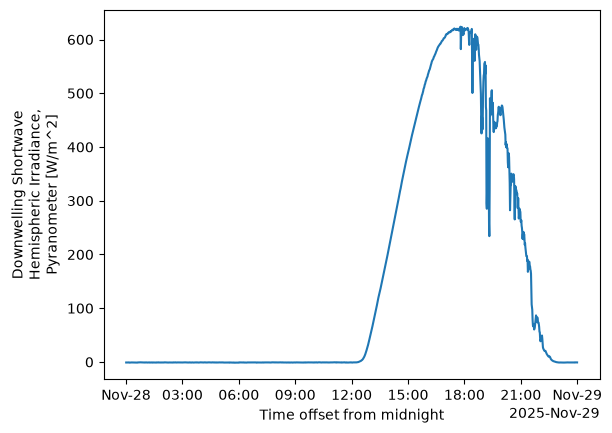

In [22]:
dsorig.down_short_hemisp.plot()

In [18]:
import atmPy.radiation.retrievals.broadband_longwave_radiation as atmbr
import atmPy.general.measurement_site as atmsite


In [57]:
site = atmsite.Station(
        lat=34.3437276,
        lon=-87.35044401,
        alt=284,
        name='tower',
        abbreviation='S10_top',
        active=None,
        operation_period=None,
        info=None,
        state='',
        country='',
        parent_network=None,
        # **kwargs,
    )

In [77]:
reload(atmbr)

<module 'atmPy.radiation.retrievals.broadband_longwave_radiation' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/broadband_longwave_radiation.py'>

In [78]:
rename = {'time': 'datetime',
         'down_long_hemisp': 'downwelling_longwave_irradiation',
         'temp_mean': 'temperature'}
ds = dsorig.rename(rename)
ds['temperature'] = ds.temperature + 273.15
ds.temperature.attrs['units'] = 'K'

In [79]:
dli = atmbr.DownwellingLongwaveIrradiation(ds, site)

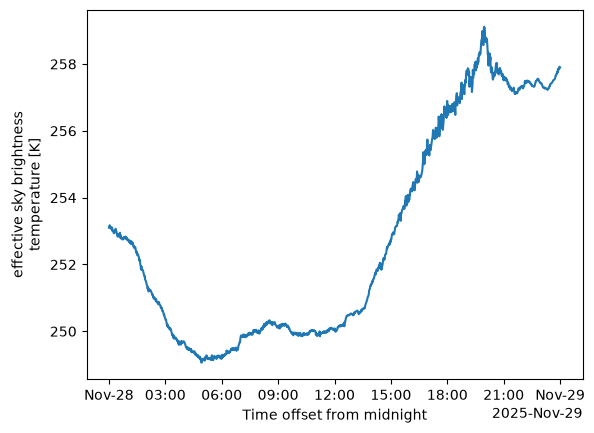

In [80]:
dli.sky_brightness_temperature.plot()

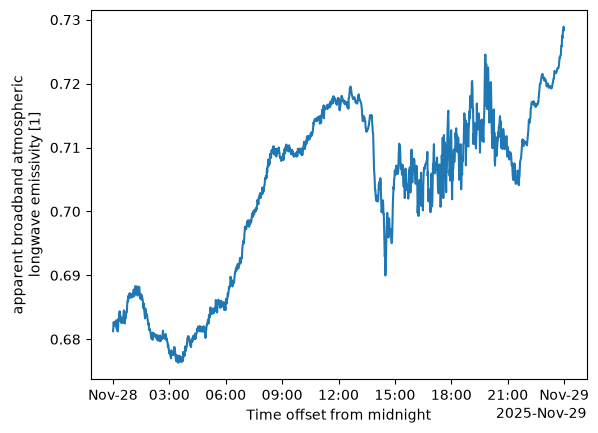

In [83]:
dli.apparent_atmospheric_emissivity.plot()

In [74]:
dli.sky_brightness_temperature

<xarray.DataArray 'sky_brightness_temperature' (datetime: 1440)> Size: 6kB
array([253.09799, 253.13522, 253.17441, ..., 257.8735 , 257.92035,
       257.89633], shape=(1440,), dtype=float32)
Coordinates:
  * datetime  (datetime) datetime64[ns] 12kB 2025-11-28T00:00:30 ... 2025-11-...
Attributes:
    standard_name:  brightness_temperature
    long_name:      effective sky brightness temperature
    units:          K
    comment:        Equivalent blackbody temperature derived from surface dow...

# NEXT, check what bob has to say

In [67]:
dsorig.rename({'time':'datetime'})

<xarray.Dataset> Size: 336kB
Dimensions:                                    (datetime: 1440, bound: 2)
Coordinates:
  * datetime                                   (datetime) datetime64[ns] 12kB ...
Dimensions without coordinates: bound
Data variables: (12/50)
    base_time                                  datetime64[ns] 8B ...
    time_offset                                (datetime) datetime64[ns] 12kB ...
    time_bounds                                (datetime, bound) datetime64[ns] 23kB ...
    down_short_hemisp                          (datetime) float32 6kB ...
    qc_down_short_hemisp                       (datetime) int32 6kB ...
    down_short_hemisp_clearsky                 (datetime) float64 12kB ...
    ...                                         ...
    rh_mean_std                                (datetime) float32 6kB ...
    clean_flag                                 (datetime) float32 6kB ...
    solar_zenith                               (datetime) float64 12kB ...
    solar_azimuth                              (datetime) float64 12kB ...
    solar_airmass                              (datetime) float64 12kB ...
    solar_sun_earth_distance                   (datetime) float64 12kB ...
Attributes: (12/35)
    Conventions:                   ARM-1.3
    process_version:               0.2
    dod_version:                   radsys43m60s-b1-1.0
    input_datastreams:             bnfradsys43m60sS10.b1
    site_id:                       bnf
    platform_id:                   radsys43m60s
    ...                            ...
    lat:                           34.3437276
    lon:                           -87.35044401
    alt:                           284
    input_files:                   bnfradsys43m60sS10.b1.20251128.000030.nc
    processing_date:               2026-07-15T14:22:00.161803
    processing_server:             telg-mbp.cmdl.noaa.gov